# IMPORT PACKAGES

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import warnings
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from tabulate import tabulate
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.metrics import mean_absolute_error, mean_squared_error

# LOADING DATASET

In [2]:
file_path = r'C:\Users\admin\Desktop\causes-of-death-in-children.csv'
df = pd.read_csv(file_path)
df.head()

,Entity,Code,Year,Deaths - Malaria - Sex: Both - Age: Under 5 (Number),Deaths - HIV/AIDS - Sex: Both - Age: Under 5 (Number),Deaths - Meningitis - Sex: Both - Age: Under 5 (Number),Deaths - Nutritional deficiencies - Sex: Both - Age: Under 5 (Number),Deaths - Other neonatal disorders - Sex: Both - Age: Under 5 (Number),Deaths - Whooping cough - Sex: Both - Age: Under 5 (Number),Deaths - Lower respiratory infections - Sex: Both - Age: Under 5 (Number),Deaths - Congenital birth defects - Sex: Both - Age: Under 5 (Number),Deaths - Measles - Sex: Both - Age: Under 5 (Number),Deaths - Neonatal sepsis and other neonatal infections - Sex: Both - Age: Under 5 (Number),Deaths - Neonatal encephalopathy due to birth asphyxia and trauma - Sex: Both - Age: Under 5 (Number),Deaths - Drowning - Sex: Both - Age: Under 5 (Number),Deaths - Tuberculosis - Sex: Both - Age: Under 5 (Number),Deaths - Neonatal preterm birth - Sex: Both - Age: Under 5 (Number),Deaths - Diarrheal diseases - Sex: Both - Age: Under 5 (Number),Deaths - Neoplasms - Sex: Both - Age: Under 5 (Number),Deaths - Syphilis - Sex: Both - Age: Under 5 (Number)
0,Afghanistan,AFG,1990,21,10,1709,1779,7112,2455,20224,12850,8649,420,1599,776,808,6088,3968,431,123
1,Afghanistan,AFG,1991,41,12,1743,1822,7574,2385,20879,13701,8669,520,1804,748,800,6791,4650,439,132
2,Afghanistan,AFG,1992,51,13,1954,2069,8614,2370,23585,15812,8539,662,2160,777,863,8098,5833,486,180
3,Afghanistan,AFG,1993,24,16,2252,2427,9458,2659,27116,17855,8949,723,2414,872,979,9142,7800,549,239
4,Afghanistan,AFG,1994,52,19,2446,2649,9823,3187,29271,18835,10642,736,2519,961,1064,9575,7894,589,259


# EDA 

In [3]:
# Remove specific parts from column names
df.columns = df.columns.str.replace(r' - Sex: Both - Age: Under 5 \(Number\)', '', regex=True)

In [4]:
df.columns = df.columns.str.replace(r'Deaths - ', '', regex=True)

In [5]:
df.head()

,Entity,Code,Year,Malaria,HIV/AIDS,Meningitis,Nutritional deficiencies,Other neonatal disorders,Whooping cough,Lower respiratory infections,Congenital birth defects,Measles,Neonatal sepsis and other neonatal infections,Neonatal encephalopathy due to birth asphyxia and trauma,Drowning,Tuberculosis,Neonatal preterm birth,Diarrheal diseases,Neoplasms,Syphilis
0,Afghanistan,AFG,1990,21,10,1709,1779,7112,2455,20224,12850,8649,420,1599,776,808,6088,3968,431,123
1,Afghanistan,AFG,1991,41,12,1743,1822,7574,2385,20879,13701,8669,520,1804,748,800,6791,4650,439,132
2,Afghanistan,AFG,1992,51,13,1954,2069,8614,2370,23585,15812,8539,662,2160,777,863,8098,5833,486,180
3,Afghanistan,AFG,1993,24,16,2252,2427,9458,2659,27116,17855,8949,723,2414,872,979,9142,7800,549,239
4,Afghanistan,AFG,1994,52,19,2446,2649,9823,3187,29271,18835,10642,736,2519,961,1064,9575,7894,589,259


In [6]:
df.shape
print("======================Column names:===================\n", df.columns)
print("===============Data types:==========================\n", df.dtypes)
print("\n==============Summary statistics=====================:")
print(df.describe())
print("\n=========Missing values:=====================")
print(df.isnull().sum().sum())
print("\n====std=======")
print(df.std(numeric_only=True))
print("\n====unique values=======")
df.nunique()


======================Column names:===================
 Index(['Entity', 'Code', 'Year', 'Malaria', 'HIV/AIDS', 'Meningitis',
       'Nutritional deficiencies', 'Other neonatal disorders',
       'Whooping cough', 'Lower respiratory infections',
       'Congenital birth defects', 'Measles',
       'Neonatal sepsis and other neonatal infections',
       'Neonatal encephalopathy due to birth asphyxia and trauma', 'Drowning',
       'Tuberculosis', 'Neonatal preterm birth', 'Diarrheal diseases',
       'Neoplasms', 'Syphilis'],
      dtype='object')
===============Data types:==========================
 Entity                                                      object
Code                                                        object
Year                                                         int64
Malaria                                                      int64
HIV/AIDS                                                     int64
Meningitis                                                

Entity                                                       228
Code                                                         205
Year                                                          30
Malaria                                                     1761
HIV/AIDS                                                    1683
Meningitis                                                  2133
Nutritional deficiencies                                    2178
Other neonatal disorders                                    2698
Whooping cough                                              1984
Lower respiratory infections                                3350
Congenital birth defects                                    3351
Measles                                                     2029
Neonatal sepsis and other neonatal infections               2470
Neonatal encephalopathy due to birth asphyxia and trauma    3028
Drowning                                                    1622
Tuberculosis             

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839
Data columns (total 20 columns):
 #   Column                                                    Non-Null Count  Dtype 
---  ------                                                    --------------  ----- 
 0   Entity                                                    6840 non-null   object
 1   Code                                                      6150 non-null   object
 2   Year                                                      6840 non-null   int64 
 3   Malaria                                                   6840 non-null   int64 
 4   HIV/AIDS                                                  6840 non-null   int64 
 5   Meningitis                                                6840 non-null   int64 
 6   Nutritional deficiencies                                  6840 non-null   int64 
 7   Other neonatal disorders                                  6840 non-null   int64 
 8   Whooping cough              

In [8]:
unique_countries = df['Entity'].unique()
print(unique_countries)

['Afghanistan' 'African Region (WHO)' 'Albania' 'Algeria' 'American Samoa'
 'Andorra' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan'
 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cape Verde' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica' "Cote d'Ivoire" 'Croatia'
 'Cuba' 'Cyprus' 'Czechia' 'Democratic Republic of Congo' 'Denmark'
 'Djibouti' 'Dominica' 'Dominican Republic' 'East Asia & Pacific (WB)'
 'Eastern Mediterranean Region (WHO)' 'Ecuador' 'Egypt' 'El Salvador'
 'England' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Europe & Central Asia (WB)' 'European Region (WHO)' 'Fiji' 'Finland'
 'France' 'G20' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece'
 'Greenland' 'Grenad

In [9]:
unique_code = df['Code'].unique()
print(unique_code)

['AFG' nan 'ALB' 'DZA' 'ASM' 'AND' 'AGO' 'ATG' 'ARG' 'ARM' 'AUS' 'AUT'
 'AZE' 'BHS' 'BHR' 'BGD' 'BRB' 'BLR' 'BEL' 'BLZ' 'BEN' 'BMU' 'BTN' 'BOL'
 'BIH' 'BWA' 'BRA' 'BRN' 'BGR' 'BFA' 'BDI' 'KHM' 'CMR' 'CAN' 'CPV' 'CAF'
 'TCD' 'CHL' 'CHN' 'COL' 'COM' 'COG' 'COK' 'CRI' 'CIV' 'HRV' 'CUB' 'CYP'
 'CZE' 'COD' 'DNK' 'DJI' 'DMA' 'DOM' 'ECU' 'EGY' 'SLV' 'GNQ' 'ERI' 'EST'
 'SWZ' 'ETH' 'FJI' 'FIN' 'FRA' 'GAB' 'GMB' 'GEO' 'DEU' 'GHA' 'GRC' 'GRL'
 'GRD' 'GUM' 'GTM' 'GIN' 'GNB' 'GUY' 'HTI' 'HND' 'HUN' 'ISL' 'IND' 'IDN'
 'IRN' 'IRQ' 'IRL' 'ISR' 'ITA' 'JAM' 'JPN' 'JOR' 'KAZ' 'KEN' 'KIR' 'KWT'
 'KGZ' 'LAO' 'LVA' 'LBN' 'LSO' 'LBR' 'LBY' 'LTU' 'LUX' 'MDG' 'MWI' 'MYS'
 'MDV' 'MLI' 'MLT' 'MHL' 'MRT' 'MUS' 'MEX' 'FSM' 'MDA' 'MCO' 'MNG' 'MNE'
 'MAR' 'MOZ' 'MMR' 'NAM' 'NRU' 'NPL' 'NLD' 'NZL' 'NIC' 'NER' 'NGA' 'NIU'
 'PRK' 'MKD' 'MNP' 'NOR' 'OMN' 'PAK' 'PLW' 'PSE' 'PAN' 'PNG' 'PRY' 'PER'
 'PHL' 'POL' 'PRT' 'PRI' 'QAT' 'ROU' 'RUS' 'RWA' 'KNA' 'LCA' 'VCT' 'WSM'
 'SMR' 'STP' 'SAU' 'SEN' 'SRB' 'SYC' 'SLE' 'SGP' 'SVK

In [10]:

warnings.filterwarnings("ignore", category=UserWarning)

In [11]:
df.columns

Index(['Entity', 'Code', 'Year', 'Malaria', 'HIV/AIDS', 'Meningitis',
       'Nutritional deficiencies', 'Other neonatal disorders',
       'Whooping cough', 'Lower respiratory infections',
       'Congenital birth defects', 'Measles',
       'Neonatal sepsis and other neonatal infections',
       'Neonatal encephalopathy due to birth asphyxia and trauma', 'Drowning',
       'Tuberculosis', 'Neonatal preterm birth', 'Diarrheal diseases',
       'Neoplasms', 'Syphilis'],
      dtype='object')

# DATA MANIPULATION

In [12]:
print("\nHandling Missing Values...")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


Handling Missing Values...
Code    690
dtype: int64


In [13]:
df['Code'] = df['Code'].fillna('Unknown')

In [14]:
print(df.isnull().sum().sum())

0


# LABEL ENCODER

In [15]:

label_encoder_code = LabelEncoder()
label_encoder_entity = LabelEncoder()
df['Code_encoded'] = label_encoder_code.fit_transform(df['Code'])
df['Entity_encoded'] = label_encoder_entity.fit_transform(df['Entity'])
df.head()

,Entity,Code,Year,Malaria,HIV/AIDS,Meningitis,Nutritional deficiencies,Other neonatal disorders,Whooping cough,Lower respiratory infections,...,Neonatal sepsis and other neonatal infections,Neonatal encephalopathy due to birth asphyxia and trauma,Drowning,Tuberculosis,Neonatal preterm birth,Diarrheal diseases,Neoplasms,Syphilis,Code_encoded,Entity_encoded
0,Afghanistan,AFG,1990,21,10,1709,1779,7112,2455,20224,...,420,1599,776,808,6088,3968,431,123,0,0
1,Afghanistan,AFG,1991,41,12,1743,1822,7574,2385,20879,...,520,1804,748,800,6791,4650,439,132,0,0
2,Afghanistan,AFG,1992,51,13,1954,2069,8614,2370,23585,...,662,2160,777,863,8098,5833,486,180,0,0
3,Afghanistan,AFG,1993,24,16,2252,2427,9458,2659,27116,...,723,2414,872,979,9142,7800,549,239,0,0
4,Afghanistan,AFG,1994,52,19,2446,2649,9823,3187,29271,...,736,2519,961,1064,9575,7894,589,259,0,0


#  Correlation Matrix

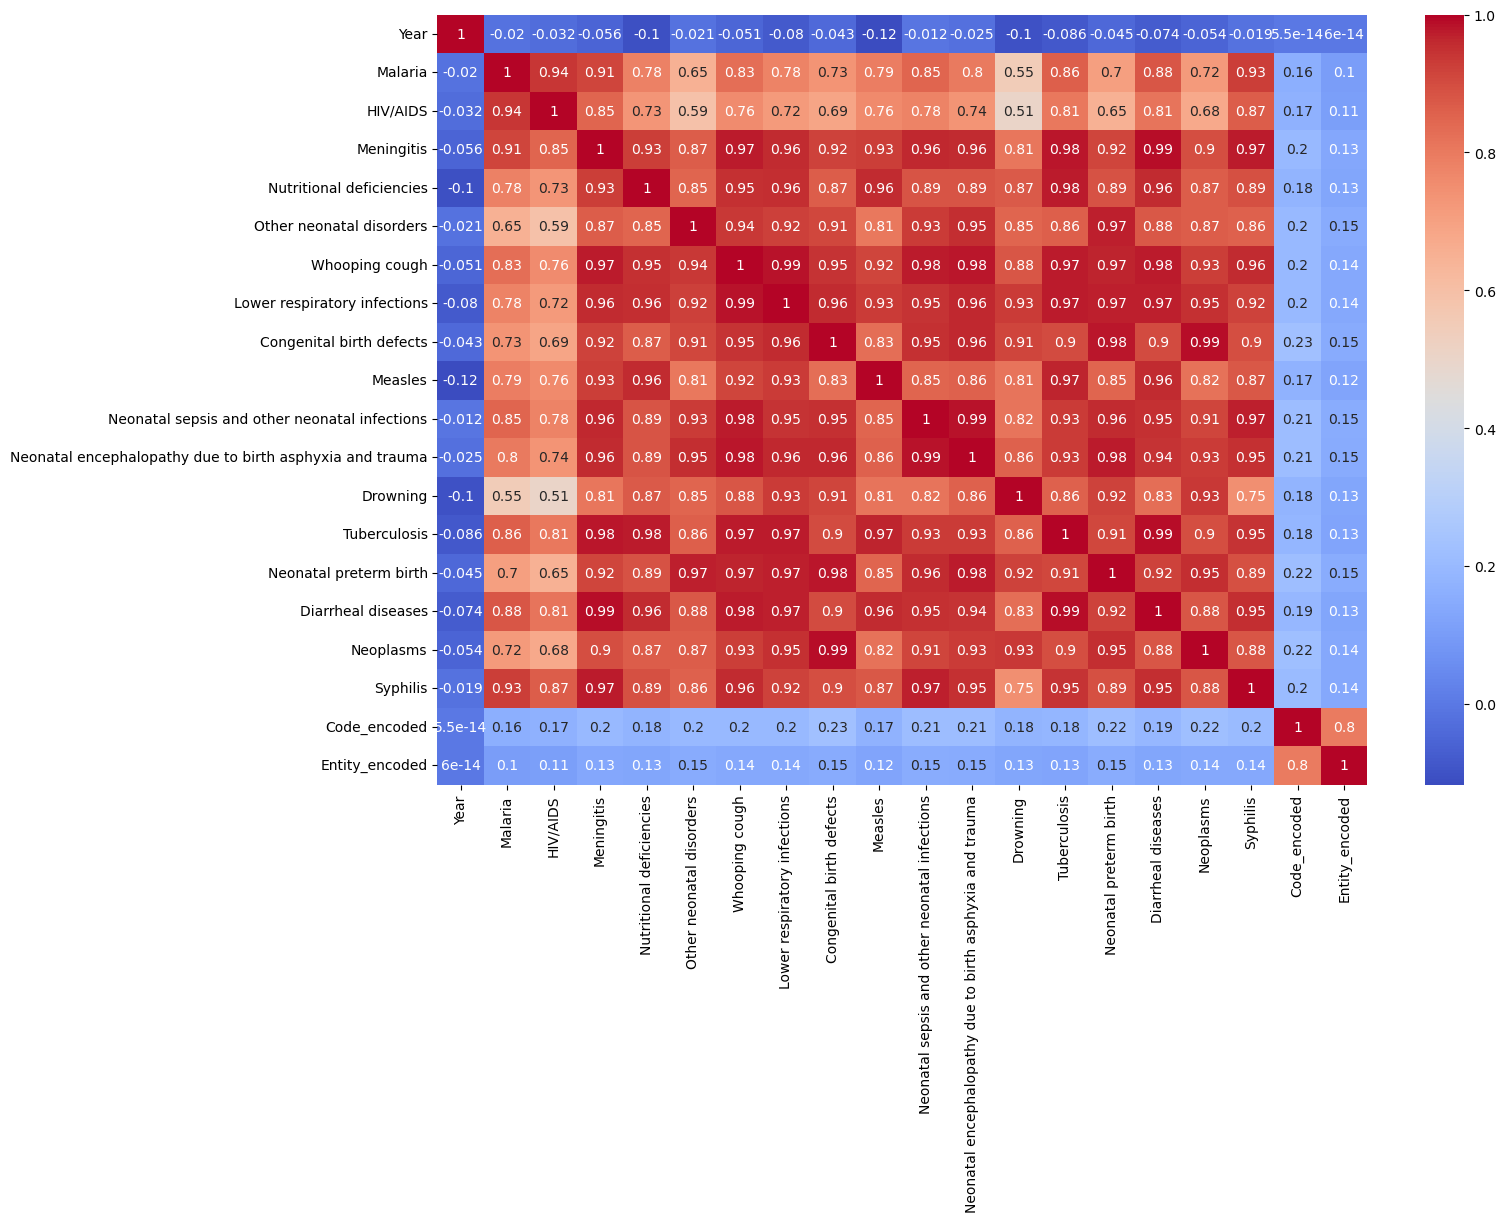

In [16]:
corr = df.corr(numeric_only=True) 
plt.figure(figsize=(15,10)) 
sns.heatmap(corr, annot=True, cmap='coolwarm') 
plt.show()

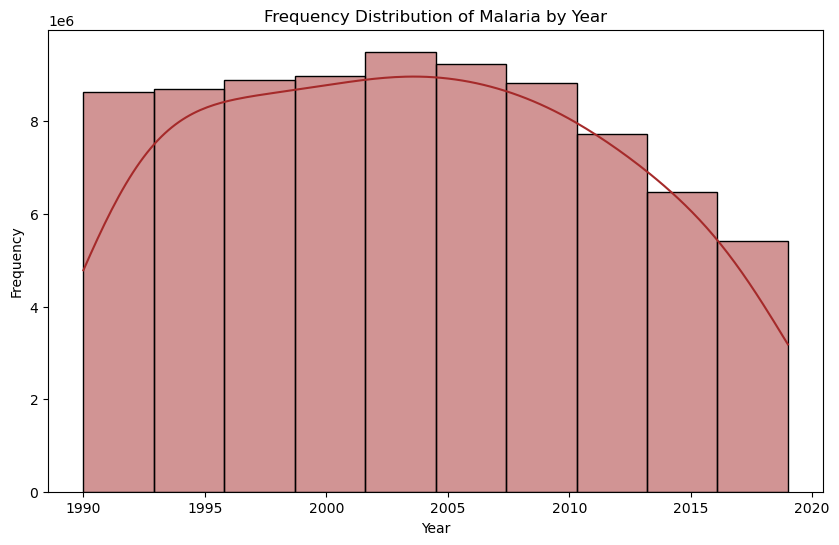

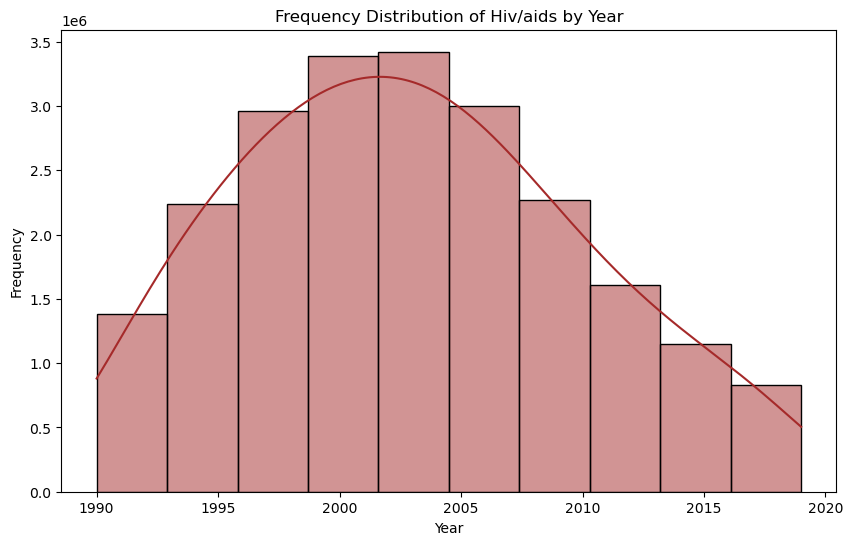

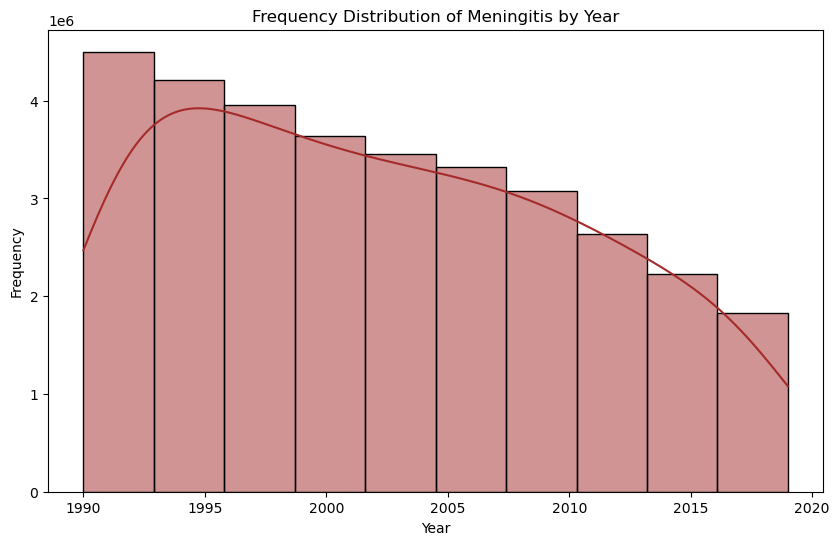

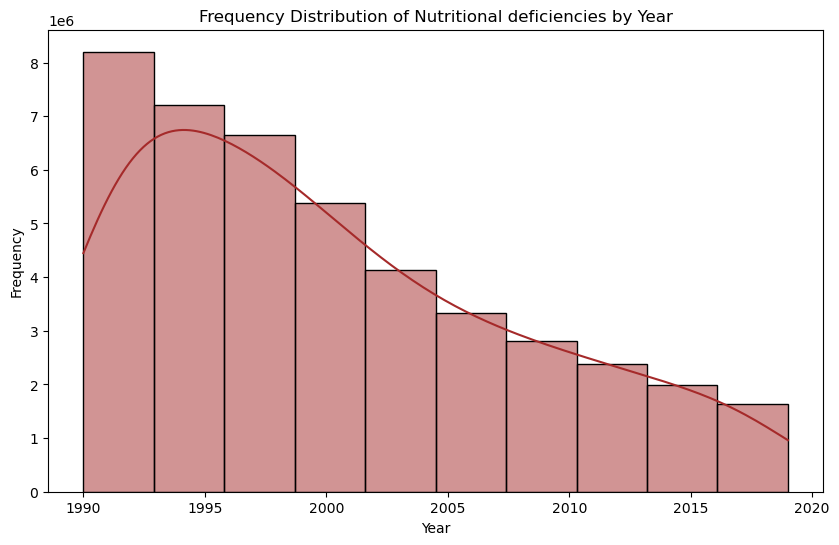

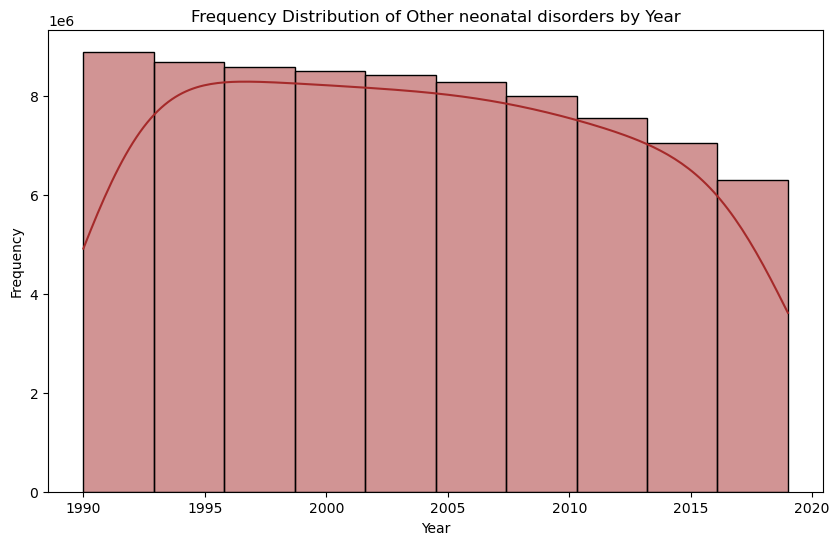

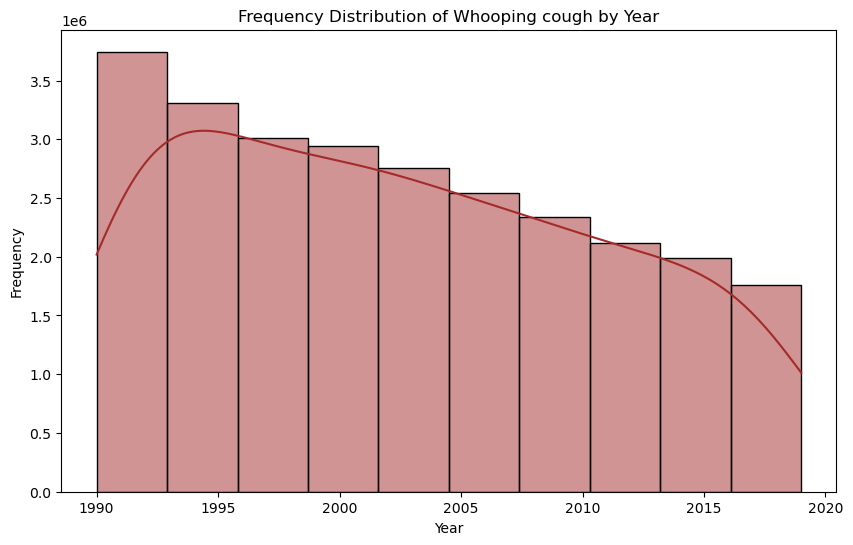

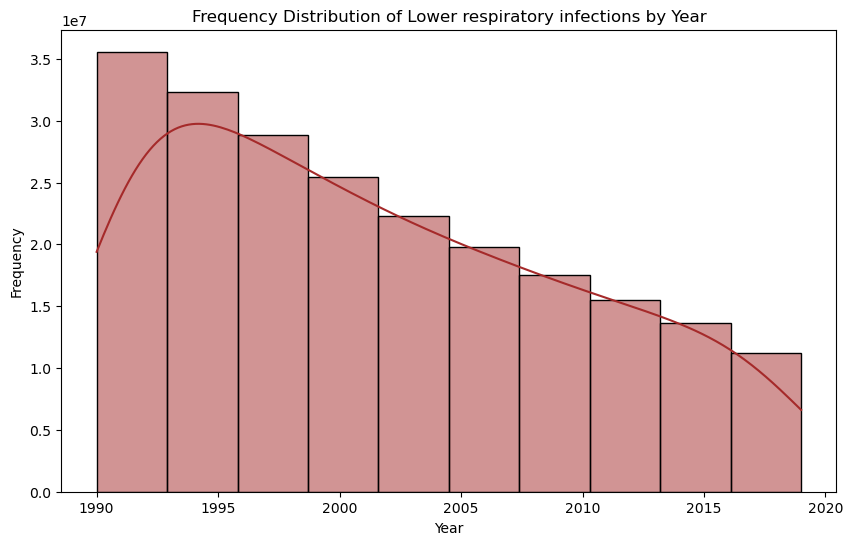

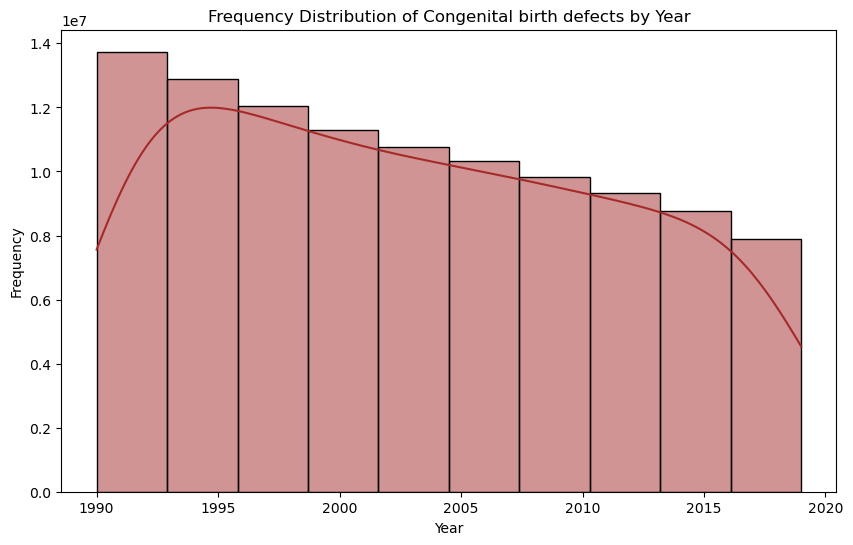

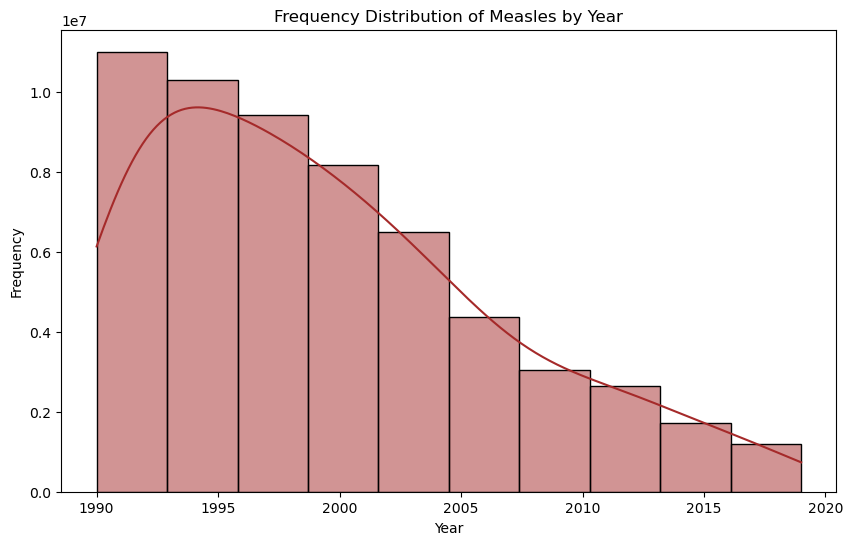

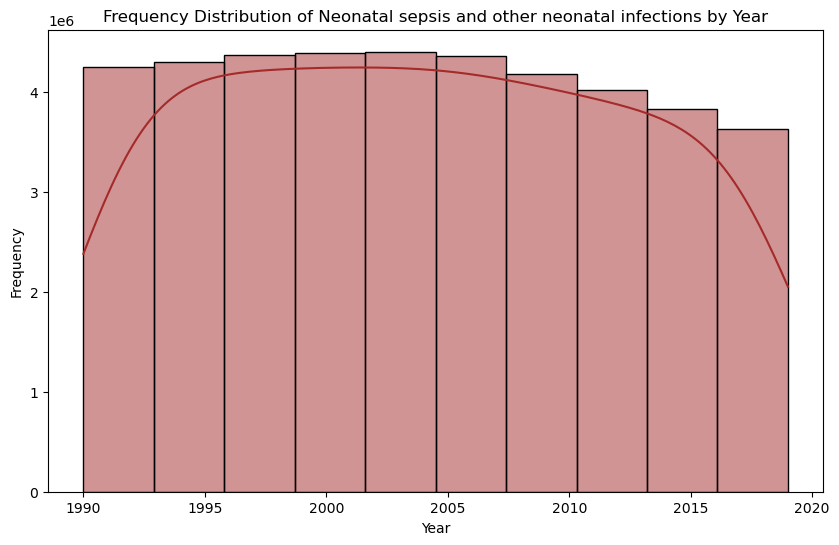

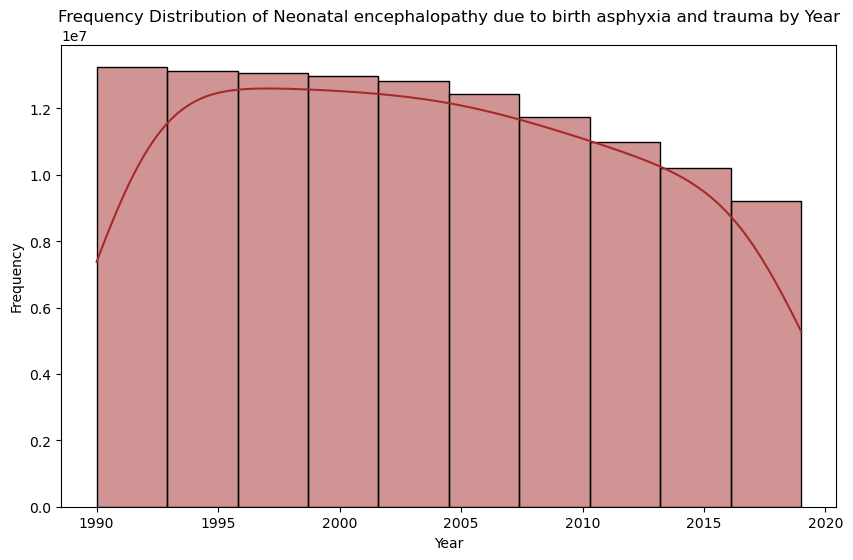

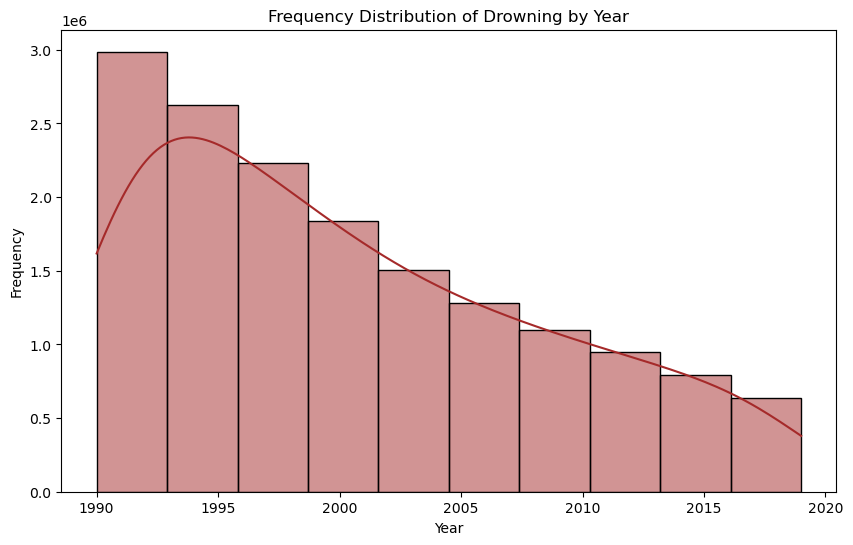

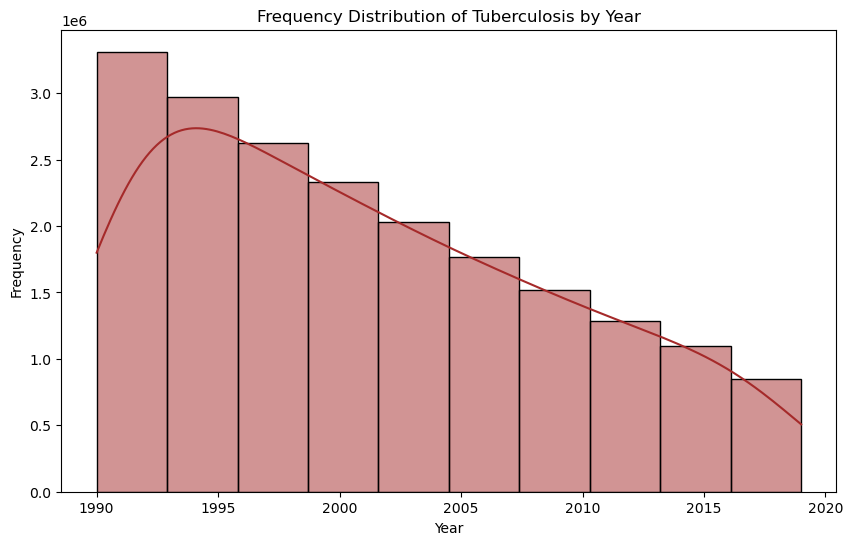

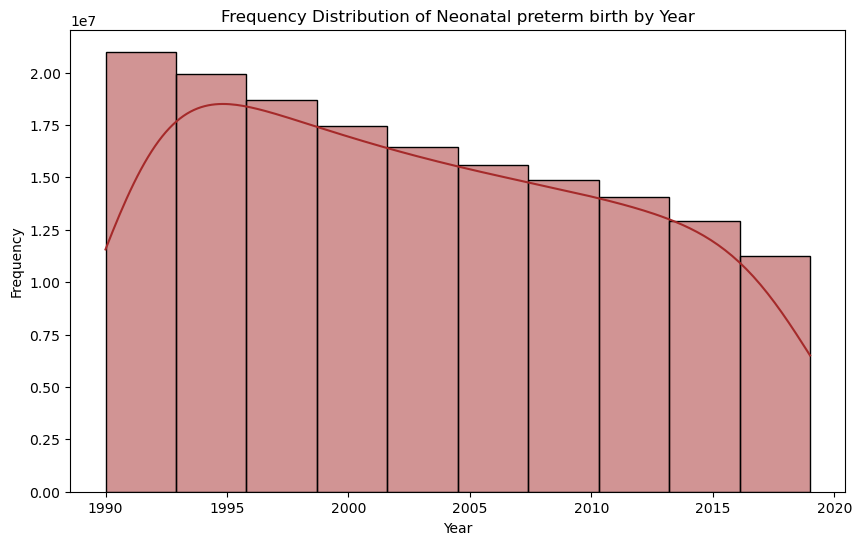

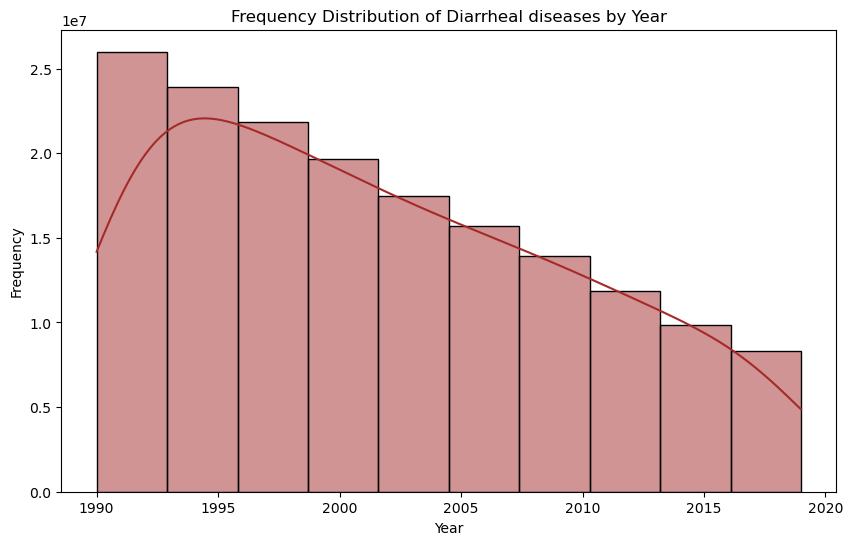

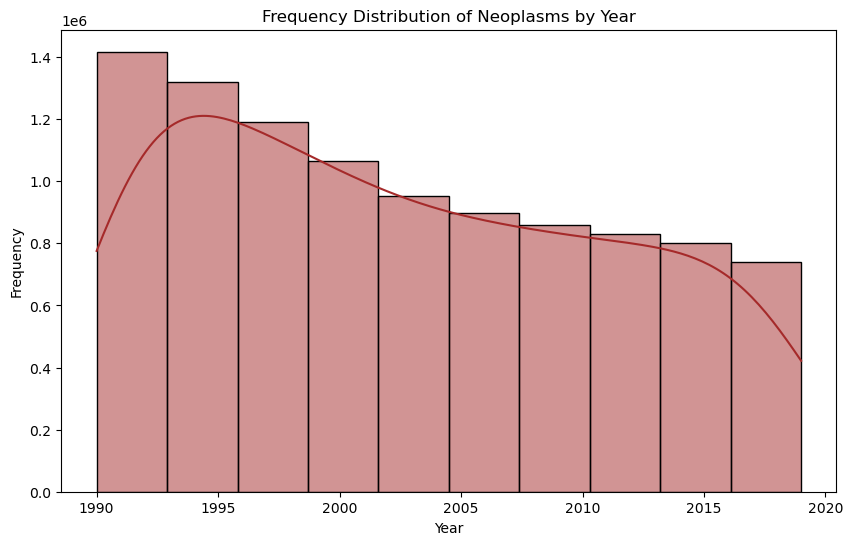

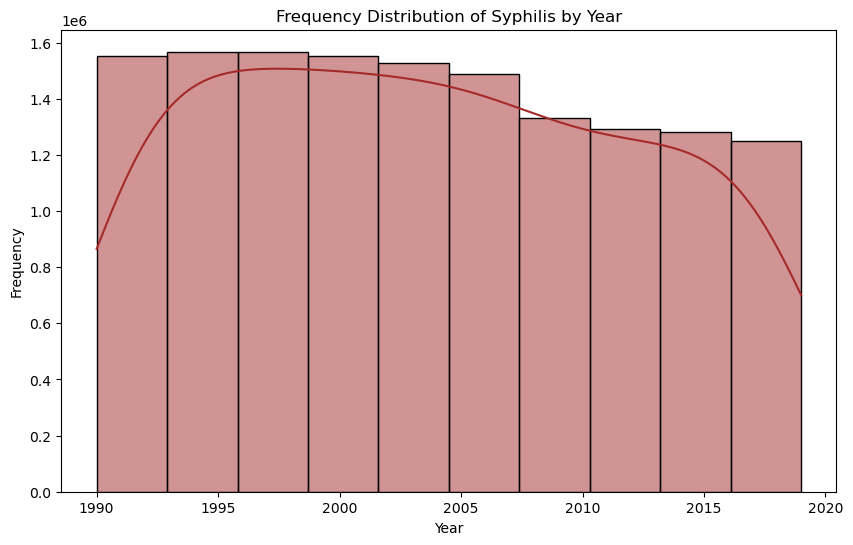

In [17]:
columns_to_plot = ['Malaria', 'HIV/AIDS', 'Meningitis',
                   'Nutritional deficiencies', 'Other neonatal disorders',
                   'Whooping cough', 'Lower respiratory infections',
                   'Congenital birth defects', 'Measles',
                   'Neonatal sepsis and other neonatal infections',
                   'Neonatal encephalopathy due to birth asphyxia and trauma', 'Drowning',
                   'Tuberculosis', 'Neonatal preterm birth', 'Diarrheal diseases',
                   'Neoplasms', 'Syphilis']
for column in columns_to_plot:
    plt.figure(figsize=(10, 6))  
    sns.histplot(df, x='Year', weights=df[column], color='brown', kde=True)
    plt.title(f'Frequency Distribution of {column.capitalize()} by Year')
    plt.xlabel('Year')
    plt.ylabel('Frequency')
    plt.show()

Enter the disease name (e.g., Malaria, HIV/AIDS, Tuberculosis): Malaria


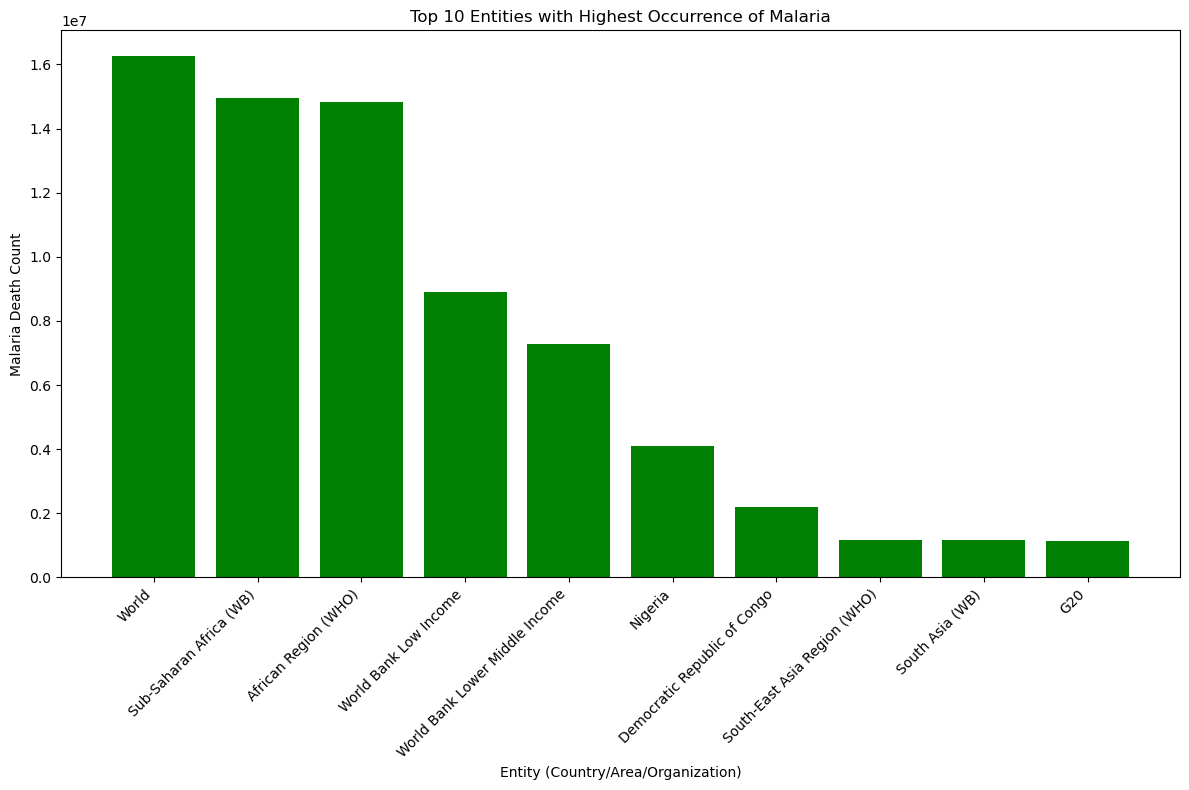

In [18]:

disease_name = input("Enter the disease name (e.g., Malaria, HIV/AIDS, Tuberculosis): ")

if disease_name in df.columns:
    
    disease_counts = df[['Entity', disease_name]].groupby('Entity')[disease_name].sum().reset_index()
    top_10_disease = disease_counts.sort_values(by=disease_name, ascending=False).head(10)
    plt.figure(figsize=(12, 8))
    plt.bar(top_10_disease['Entity'], top_10_disease[disease_name], color='green')
    plt.title(f'Top 10 Entities with Highest Occurrence of {disease_name}')
    plt.xlabel('Entity (Country/Area/Organization)')
    plt.ylabel(f'{disease_name} Death Count')
    plt.xticks(rotation=45, ha='right')  
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: The disease '{disease_name}' does not exist in the dataset. Please check your input.")

Enter the country or region (e.g., India, Pakistan, Afghanistan): Pakistan


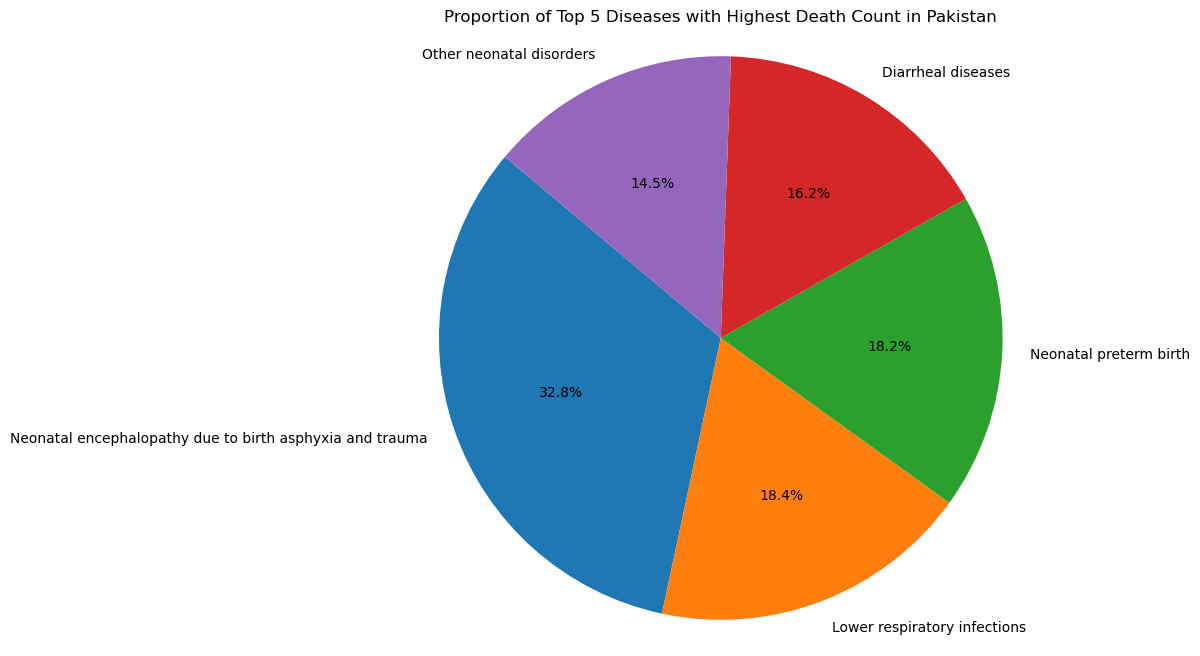

In [20]:

entity_name = input("Enter the country or region (e.g., India, Pakistan, Afghanistan): ")

entity_data = df[df['Entity'] == entity_name]

if not entity_data.empty:
    disease_columns = [col for col in df.columns if col not in ['Entity', 'Code', 'Year','Code_encoded','Entity_encoded']]
    disease_death_counts_entity = entity_data[disease_columns].sum()
    top_5_diseases_entity = disease_death_counts_entity.nlargest(5)
    plt.figure(figsize=(8, 8))
    plt.pie(top_5_diseases_entity, labels=top_5_diseases_entity.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Proportion of Top 5 Diseases with Highest Death Count in {entity_name}')
    plt.axis('equal')  
    plt.show()
else:
    print(f"Error: No data found for the entity '{entity_name}'. Please check your input.")


Enter the country or region (e.g., Pakistan, India, Afghanistan): India


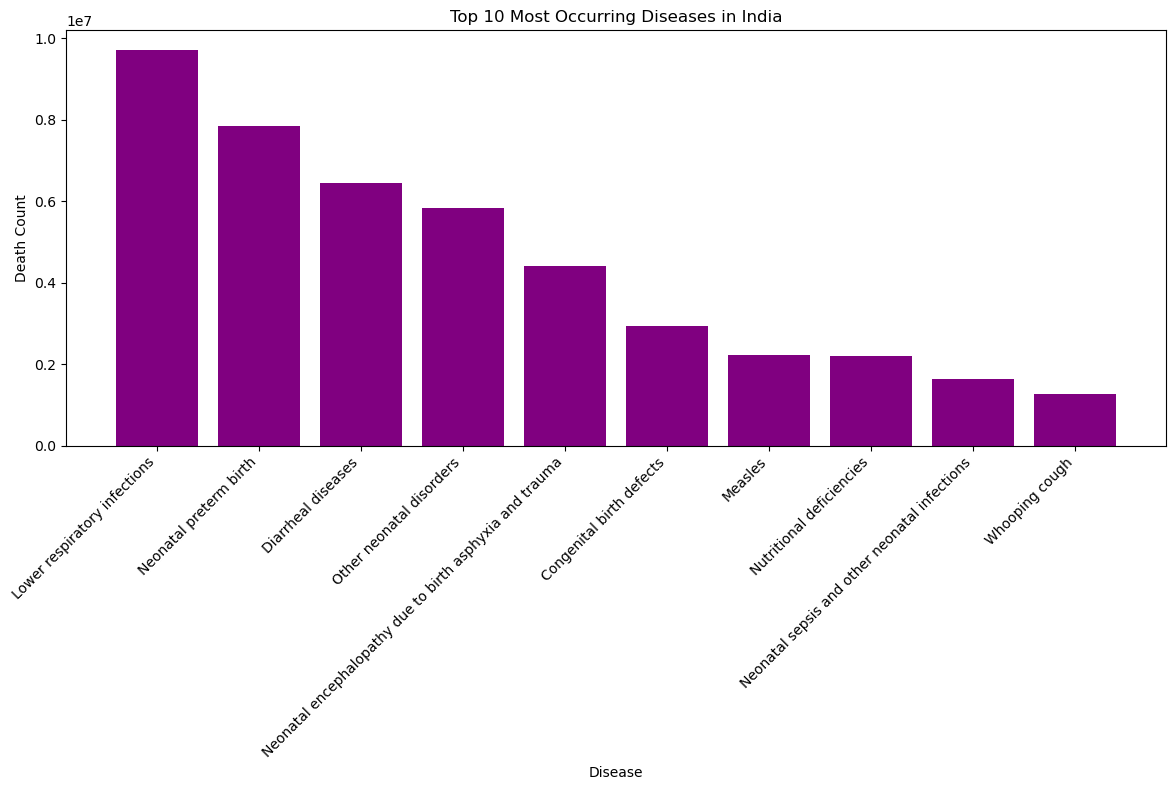

In [21]:
entity_name = input("Enter the country or region (e.g., Pakistan, India, Afghanistan): ")
entity_data = df[df['Entity'] == entity_name]

if not entity_data.empty:
    
    disease_columns = [col for col in df.columns if col not in ['Entity', 'Code', 'Year','Code_encoded','Entity_encoded']]
    entity_diseases = entity_data[disease_columns].sum()
    top_10_diseases_entity = entity_diseases.sort_values(ascending=False).head(10)
    plt.figure(figsize=(12, 8))
    plt.bar(top_10_diseases_entity.index, top_10_diseases_entity.values, color='purple')
    plt.title(f'Top 10 Most Occurring Diseases in {entity_name}')
    plt.xlabel('Disease')
    plt.ylabel('Death Count')
    plt.xticks(rotation=45, ha='right')  

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: No data found for the entity '{entity_name}'. Please check your input.")

Enter the country or region (e.g., Algeria, India, Pakistan): Afghanistan


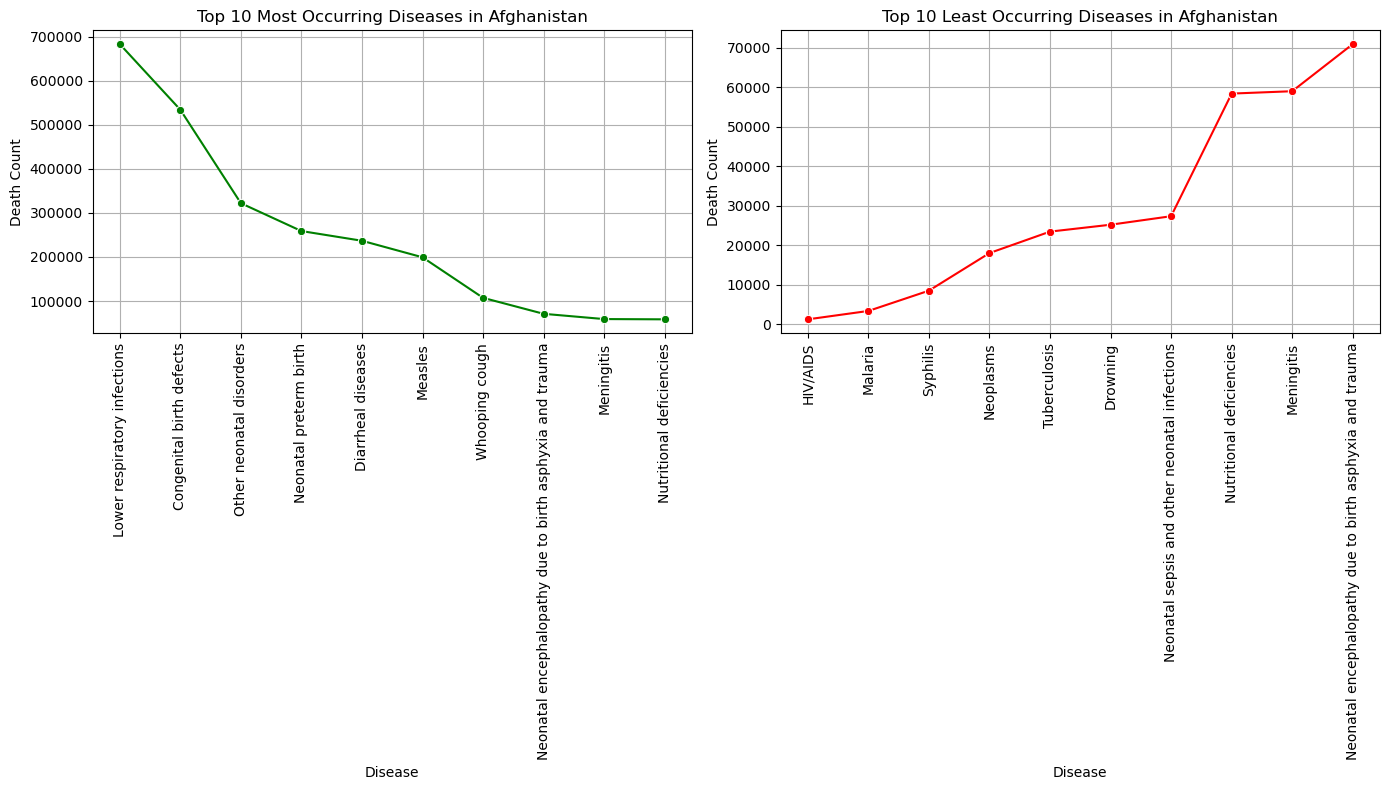

In [22]:
entity_name = input("Enter the country or region (e.g., Algeria, India, Pakistan): ")

entity_data = df[df['Entity'] == entity_name]

if not entity_data.empty:
    
    disease_columns = [col for col in df.columns if col not in ['Entity', 'Code', 'Year','Code_encoded','Entity_encoded']]

    disease_death_counts_entity = entity_data[disease_columns].sum()
    top_10_max_diseases = disease_death_counts_entity.nlargest(10)
    top_10_min_diseases = disease_death_counts_entity.nsmallest(10)
    plt.figure(figsize=(14, 8))

    plt.subplot(1, 2, 1)
    sns.lineplot(x=top_10_max_diseases.index, y=top_10_max_diseases.values, marker='o', color='green')
    plt.title(f'Top 10 Most Occurring Diseases in {entity_name}')
    plt.xlabel('Disease')
    plt.ylabel('Death Count')
    plt.xticks(rotation=90) 
    plt.grid(True)

    # Plot for the top 10 least occurring diseases
    plt.subplot(1, 2, 2)
    sns.lineplot(x=top_10_min_diseases.index, y=top_10_min_diseases.values, marker='o', color='red')
    plt.title(f'Top 10 Least Occurring Diseases in {entity_name}')
    plt.xlabel('Disease')
    plt.ylabel('Death Count')
    plt.xticks(rotation=90)  
    plt.grid(True)

    # Adjust the layout and show the plot
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: No data found for the entity '{entity_name}'. Please check your input.")

In [23]:
# Ask user for the country/entity name
entity_name = input("Enter the Entity (e.g., Afghanistan, India, etc.): ")

# Filter data for the selected entity
entity_data = df[df['Entity'] == entity_name]

# Check if the entity data is not empty
if not entity_data.empty:
   
    disease_columns = [col for col in df.columns if col not in ['Entity', 'Code', 'Year']]

    disease_death_counts_entity = entity_data[disease_columns].sum()

    # Convert the result to a DataFrame for easier visualization
    disease_death_df = pd.DataFrame(disease_death_counts_entity).reset_index()
    disease_death_df.columns = ['Disease', 'Total Death Count']

    # Sort the diseases by total death count in descending order
    disease_death_df = disease_death_df.sort_values(by='Total Death Count', ascending=False)

    fig = px.bar(disease_death_df, x='Disease', y='Total Death Count', 
                 title=f'Top Diseases Causing Death in {entity_name}', 
                 labels={'Total Death Count': 'Number of Deaths', 'Disease': 'Disease'}, 
                 color='Total Death Count', 
                 color_continuous_scale='Viridis')

    # Customize the chart
    fig.update_layout(
        xaxis_tickangle=-45,
        width=1200,  
        height=800,  
        font=dict(color='black'),  
        hoverlabel=dict(font=dict(color='black'))  
    )

    # Show the plot
    fig.show()

else:
    print(f"No data found for the entity: {entity_name}")

Enter the Entity (e.g., Afghanistan, India, etc.): Afghanistan


In [25]:

year_input = int(input("Enter the year (e.g., 2019): "))
disease_input = input("Enter the disease (e.g., Tuberculosis): ")

data_year = df[df['Year'] == year_input]

if disease_input in data_year.columns:
    
    disease_deaths_year = data_year.groupby('Entity')[disease_input].sum().reset_index()

    top_10_disease_deaths = disease_deaths_year.sort_values(by=disease_input, ascending=False).head(10)

    fig = px.bar(top_10_disease_deaths, 
                 x='Entity', 
                 y=disease_input, 
                 title=f'Top 10 Entities with Highest Deaths Due to {disease_input} in {year_input}', 
                 labels={'Entity': 'Country/Entity', disease_input: f'Total Deaths due to {disease_input}'},
                 color=disease_input,
                 color_continuous_scale='Viridis')

 
    fig.update_layout(
        xaxis_tickangle=45, 
        showlegend=False,
        width=1200,  
        height=800   
    )

    # Show the chart
    fig.show()

else:
    print(f"Error: {disease_input} data not available in the year {year_input}.")

Enter the year (e.g., 2019): 2018
Enter the disease (e.g., Tuberculosis): Malaria


# APPLYING REGRESSION ML MODELS

In [36]:
def preprocess_data(df, region, disease):
    df_region = df[df['Entity'] == region]
    df_region = df_region[['Year', disease]].dropna()  # Remove rows with missing values
    
    X = df_region[['Year']]  # Independent variable: Year
    y = df_region[disease]   # Dependent variable: Disease
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scaling (Standardization)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [37]:
def evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test):
    # Train KNN model
    knn_reg_model = KNeighborsRegressor(n_neighbors=5)
    knn_reg_model.fit(X_train_scaled, y_train)
    y_pred_knn = knn_reg_model.predict(X_test_scaled)
    rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

    # Train Linear Regression model
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    y_pred_lr = lr_model.predict(X_test_scaled)
    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

    # Train Decision Tree model
    dt_reg_model = DecisionTreeRegressor(random_state=42)
    dt_reg_model.fit(X_train_scaled, y_train)
    y_pred_dt = dt_reg_model.predict(X_test_scaled)
    rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

    # Compare RMSE and select the best model
    print(f"Model RMSE Scores:\nKNN: {rmse_knn:.2f}, Linear Regression: {rmse_lr:.2f}, Decision Tree: {rmse_dt:.2f}")
    if rmse_knn <= rmse_lr and rmse_knn <= rmse_dt:
        return knn_reg_model, "KNN Regressor"
    elif rmse_lr <= rmse_knn and rmse_lr <= rmse_dt:
        return lr_model, "Linear Regression"
    else:
        return dt_reg_model, "Decision Tree Regressor"

In [38]:
def predict_deaths(region, disease, year_to_predict, best_model, scaler):
    # Scale the input year
    year_scaled = scaler.transform([[year_to_predict]])  # Scale the input year
    predicted_deaths = best_model.predict(year_scaled)
    print(f"Predicted deaths for {disease} in {region} in {year_to_predict}: {predicted_deaths[0]:.0f}")

In [39]:
try:
    # Step 1: Get user input
    region = input("Enter the region (e.g., Africa, Asia, Europe): ")
    disease = input("Enter the disease (e.g., Malaria, HIV/AIDS, Tuberculosis): ")
    year_to_predict = int(input("Enter the year you want to predict: "))
    
    # Step 2: Preprocess the data
    X_train_scaled, X_test_scaled, y_train, y_test, scaler = preprocess_data(df, region, disease)

    # Step 3: Train models and evaluate RMSE
    best_model, best_model_name = evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test)
    
    print(f"The best model is {best_model_name}.")

    # Step 4: Predict deaths using the best model
    predict_deaths(region, disease, year_to_predict, best_model, scaler)

except ValueError as e:
    print(f"Error: {e}")


Enter the region (e.g., Africa, Asia, Europe): Afghanistan
Enter the disease (e.g., Malaria, HIV/AIDS, Tuberculosis): Malaria
Enter the year you want to predict: 2030
Model RMSE Scores:
KNN: 94.61, Linear Regression: 46.25, Decision Tree: 53.86
The best model is Linear Regression.
Predicted deaths for Malaria in Afghanistan in 2030: 111


# CLASSIFICATION ANALYSIS

# Analysis By Entity

In [26]:
def preprocess_top_diseases_data(df, country, year):
    # Filter data for the selected country and year
    df_filtered = df[(df['Entity'] == country) & (df['Year'] == year)]
    
    if df_filtered.empty:
        raise ValueError(f"No data available for the selected country ({country}) and year ({year}).")
    
    disease_columns = [col for col in df.columns if col not in ['Entity', 'Code', 'Year']]
    
    
    if df_filtered[disease_columns].isnull().all().all():
        raise ValueError(f"No death count data for any diseases in {country} in {year}.")

    disease_counts = df_filtered[disease_columns].iloc[0]
  
    top_diseases = disease_counts.sort_values(ascending=False).head(5).index.tolist()
    df['High_Death_Disease'] = df[disease_columns].idxmax(axis=1)  # Add top disease as label
    
    # Encode the target variable and categorical features
    label_encoder_disease = LabelEncoder()
    df['High_Death_Disease'] = label_encoder_disease.fit_transform(df['High_Death_Disease'])
    
    label_encoder_country = LabelEncoder()
    df['Entity_encoded'] = label_encoder_country.fit_transform(df['Entity'])
    
    # Select features and target
    X = df[['Year', 'Entity_encoded']]
    y = df['High_Death_Disease']
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, top_diseases, scaler, label_encoder_disease, label_encoder_country


In [27]:
def evaluate_classifier_model(X_train_scaled, X_test_scaled, y_train, y_test):
    models = {
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42)
    }
    
    accuracies = {}
    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        accuracies[model_name] = accuracy
        print(f"{model_name} Accuracy: {accuracy:.2f}")
    
    # Select the best model
    best_model_name = max(accuracies, key=accuracies.get)
    best_model = models[best_model_name]
    print(f"Best Model: {best_model_name} with Accuracy: {accuracies[best_model_name]:.2f}")
    
    return best_model, best_model_name

In [28]:
def predict_top_diseases(country, year, classifier, scaler, label_encoder_disease, label_encoder_country, df):
    # Prepare the data for the specific country and year
    df_filtered = df[(df['Entity'] == country) & (df['Year'] == year)]
    if df_filtered.empty:
        print(f"No data available for {country} in {year}.")
        return
    
    # Extract the features
    X_predict = df_filtered[['Year', 'Entity_encoded']]  
    
    # Ensure 'Entity_encoded' is available
    if 'Entity_encoded' not in X_predict.columns:
        X_predict['Entity_encoded'] = label_encoder_country.transform(X_predict['Entity'])  # Transform if missing
    
    # Scale the features
    X_predict_scaled = scaler.transform(X_predict[['Year', 'Entity_encoded']])  # Only use relevant columns for scaling
    
    # Make predictions
    predicted_diseases = classifier.predict(X_predict_scaled)
    predicted_disease_names = label_encoder_disease.inverse_transform(predicted_diseases)
    
    print("======================================================================")
    print(f"The top diseases causing high death rates in {country} in {year} are:")
    for disease in predicted_disease_names:
        print(disease)

In [29]:
try:
    # User Input
    country = input("Enter the country name: ")
    year = int(input("Enter the year: "))
    print("=====================================")
    
    # Preprocess data
    X_train_scaled, X_test_scaled, y_train, y_test, top_diseases, scaler, label_encoder_disease, label_encoder_country = preprocess_top_diseases_data(df, country, year)
    
    # Train models and select the best one
    best_model, best_model_name = evaluate_classifier_model(X_train_scaled, X_test_scaled, y_train, y_test)
    
    # Predict top diseases
    predict_top_diseases(country, year, best_model, scaler, label_encoder_disease, label_encoder_country, df)
    
except ValueError as e:
    print(f"Error: {e}")

Enter the country name: Pakistan
Enter the year: 2012
Random Forest Accuracy: 0.27
Gradient Boosting Accuracy: 0.84
Decision Tree Accuracy: 0.95
Best Model: Decision Tree with Accuracy: 0.95
The top diseases causing high death rates in Pakistan in 2012 are:
Neonatal encephalopathy due to birth asphyxia and trauma


# Analysis By Year

In [30]:
def preprocess_top_diseases_data_by_year(df, year):
    # Filter data for the selected year
    df_filtered = df[df['Year'] == year]
    
    if df_filtered.empty:
        raise ValueError(f"No data available for the year {year}.")
   
    non_disease_columns = ['Entity', 'Code', 'Year', 'Entity_encoded', 'Code_encoded']
    disease_columns = [col for col in df.columns if col not in non_disease_columns]
    
    # Check if the dataset contains any death counts for diseases
    if df_filtered[disease_columns].isnull().all().all():
        raise ValueError(f"No death count data for any diseases in {year}.")
    
    return df_filtered, disease_columns

In [31]:
def predict_top_diseases(year, df):
    # Preprocess the data for the selected year
    df_filtered, disease_columns = preprocess_top_diseases_data_by_year(df, year)
    
    # Prepare features and target for training
    X = df[['Year', 'Entity_encoded', 'Code_encoded']] 
    y = df[disease_columns].idxmax(axis=1)  
    
    # Encode categorical features
    label_encoder_disease = LabelEncoder()
    df['High_Death_Disease'] = label_encoder_disease.fit_transform(y)
    
    label_encoder_country = LabelEncoder()
    df['Entity_encoded'] = label_encoder_country.fit_transform(df['Entity'])
    
    label_encoder_code = LabelEncoder()
    df['Code_encoded'] = label_encoder_code.fit_transform(df['Code'])
    
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train models and evaluate
    best_model, best_model_name = evaluate_classifier_model(X_train_scaled, X_test_scaled, y_train, y_test)
    
    # Predict the top diseases for the selected year
    results = []
    
    for _, row in df_filtered.iterrows():
        
        disease_counts = pd.to_numeric(row[disease_columns], errors='coerce')
        
        # Rank diseases based on death counts and select the top one
        high_cause_of_death = disease_counts.idxmax()  
        death_count = disease_counts.max()  
        
        
        if high_cause_of_death != 'High_Death_Disease': 
            results.append([row['Entity'], high_cause_of_death, death_count])
    
    # Output the results as a table, ensuring that High_Death_Disease doesn't appear
    print(f"Top cause of death by disease in {year}:")
    print(tabulate(results, headers=["Country", "Disease", "Death Count"], tablefmt="grid"))



In [32]:
# Example Usage
try:
    # User Input
    year = int(input("Enter the year: "))
    
    # Predict top diseases for the selected year
    predict_top_diseases(year, df)
    
except ValueError as e:
    print(f"Error: {e}")


Enter the year: 2016
Random Forest Accuracy: 0.72
Gradient Boosting Accuracy: 0.86
Decision Tree Accuracy: 0.94
Best Model: Decision Tree with Accuracy: 0.94
Top cause of death by disease in 2016:
+------------------------------------+----------------------------------------------------------+---------------+
| Country                            | Disease                                                  |   Death Count |
+====================================+==========================================================+===============+
| Afghanistan                        | Congenital birth defects                                 |         16910 |
+------------------------------------+----------------------------------------------------------+---------------+
| African Region (WHO)               | Lower respiratory infections                             |        406428 |
+------------------------------------+----------------------------------------------------------+---------------+
| Alb

# Analysis By Disease

In [33]:
def preprocess_top_diseases_data1(df, year):
    # Filter data for the selected year
    df_filtered = df[df['Year'] == year]
    if df_filtered.empty:
        raise ValueError(f"No data available for the year {year}.")
    
    non_disease_columns = ['Entity', 'Code', 'Year', 'Entity_encoded', 'Code_encoded']
    disease_columns = [col for col in df.columns if col not in non_disease_columns]
    
    if df_filtered[disease_columns].isnull().all().all():
        raise ValueError(f"No death count data for any diseases in {year}.")
    
    return df_filtered, disease_columns


In [34]:
def get_top_disease_countries(year, df, disease_name):
    # Preprocess the data for the selected year
    df_filtered, disease_columns = preprocess_top_diseases_data1(df, year)
    
    # Check if the selected disease exists in the columns
    if disease_name not in disease_columns:
        raise ValueError(f"{disease_name} data is missing from the dataset.")
    
    # Sort countries by the occurrence of the selected disease
    df_sorted = df_filtered[['Entity', disease_name]].sort_values(by=disease_name, ascending=False)
    
    # Get the top 5 countries
    top_5_countries = df_sorted.head(5)
    
    # Output the results as a table using tabulate
    print(f"\nThe top 5 countries with the highest occurrence of {disease_name} in {year}:")
    print(tabulate(top_5_countries[['Entity', disease_name]].values, 
                   headers=["Country", "Death Count"], tablefmt="grid"))


In [35]:
try:
    # User Input
    year = int(input("Enter the year: "))
    disease_name = input("Enter the disease name (must match exact column name): ").strip()
    print("==============================================================================")

    # Prepare features and target for training
    df_filtered, disease_columns = preprocess_top_diseases_data1(df, year)
    X = df[['Year', 'Entity_encoded', 'Code_encoded']]  # Features: Year, Entity_encoded, Code_encoded
    y = df[disease_columns].idxmax(axis=1)  # Target: Disease with highest death count
    
    # Encode categorical features
    label_encoder_disease = LabelEncoder()
    df['High_Death_Disease'] = label_encoder_disease.fit_transform(y)
    
    label_encoder_country = LabelEncoder()
    df['Entity_encoded'] = label_encoder_country.fit_transform(df['Entity'])
    
    label_encoder_code = LabelEncoder()
    df['Code_encoded'] = label_encoder_code.fit_transform(df['Code'])
    
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Evaluate classifier models and determine the best one
    best_model, best_model_name = evaluate_classifier_model(X_train_scaled, X_test_scaled, y_train, y_test)
    
    # Get the top 5 countries for the disease
    get_top_disease_countries(year, df, disease_name)
    
except ValueError as e:
    print(f"Error: {e}")


Enter the year: 2013
Enter the disease name (must match exact column name): Malaria
Random Forest Accuracy: 0.68
Gradient Boosting Accuracy: 0.87
Decision Tree Accuracy: 0.95
Best Model: Decision Tree with Accuracy: 0.95

The top 5 countries with the highest occurrence of Malaria in 2013:
+--------------------------------+---------------+
| Country                        |   Death Count |
+================================+===============+
| World                          |        481600 |
+--------------------------------+---------------+
| Sub-Saharan Africa (WB)        |        465724 |
+--------------------------------+---------------+
| African Region (WHO)           |        462857 |
+--------------------------------+---------------+
| World Bank Low Income          |        264936 |
+--------------------------------+---------------+
| World Bank Lower Middle Income |        215558 |
+--------------------------------+---------------+
